In [2]:
import pandas as pd
import psycopg2

conn = psycopg2.connect(
    dbname="crypto",
    user="postgres",
    password="1234509876",
    host="localhost",
    port="5432"
)

df = pd.read_sql("SELECT * FROM crypto_prices", conn)
conn.close()

df.head()

C:\Users\adity\AppData\Local\Temp\ipykernel_3552\338927373.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM crypto_prices", conn)


,id,name,price,timestamp
0,1,bitcoin,71494.0,2026-03-25 19:40:43.615828
1,2,bitcoin,71419.0,2026-03-25 19:43:13.081146
2,3,bitcoin,71383.0,2026-03-25 19:43:45.964923
3,4,bitcoin,71383.0,2026-03-25 19:44:18.653010
4,5,bitcoin,71392.0,2026-03-25 19:44:51.471140


In [3]:
df = df.sort_values(by='timestamp')

df['prev_price'] = df['price'].shift(1)

df = df.dropna()

df.head()

,id,name,price,timestamp,prev_price
1,2,bitcoin,71419.0,2026-03-25 19:43:13.081146,71494.0
2,3,bitcoin,71383.0,2026-03-25 19:43:45.964923,71419.0
3,4,bitcoin,71383.0,2026-03-25 19:44:18.653010,71383.0
4,5,bitcoin,71392.0,2026-03-25 19:44:51.471140,71383.0
5,6,bitcoin,71392.0,2026-03-25 19:45:23.984655,71392.0


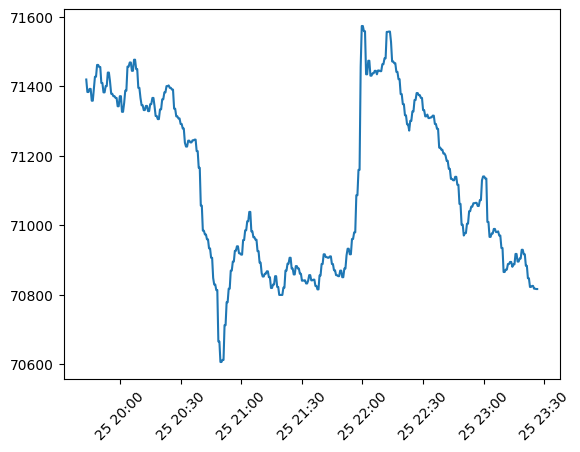

In [4]:
import matplotlib.pyplot as plt

plt.plot(df['timestamp'], df['price'])
plt.xticks(rotation=45)
plt.show()

In [13]:
df = df.sort_values(by='timestamp').reset_index(drop=True)

# Lag features
df['lag_1'] = df['price'].shift(1)
df['lag_2'] = df['price'].shift(2)
df['lag_3'] = df['price'].shift(3)

# Momentum
df['momentum_1'] = df['price'].shift(1) - df['price'].shift(2)
df['momentum_3'] = df['price'].shift(1) - df['price'].shift(4)

# Rolling stats (on past data only, no leakage)
df['rolling_mean_5']  = df['price'].shift(1).rolling(5).mean()
df['rolling_std_5']   = df['price'].shift(1).rolling(5).std()

# 👇 NEW TARGET — direction of next move
df['direction'] = (df['price'] > df['price'].shift(1)).astype(int)
# 1 = price went UP, 0 = price went DOWN

df = df.dropna()

# Check class balance
print(df['direction'].value_counts())
print(f"Total rows: {len(df)}")

direction
0    317
1     94
Name: count, dtype: int64
Total rows: 411


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

X = df[['lag_1', 'lag_2', 'lag_3',
        'momentum_1', 'momentum_3',
        'rolling_mean_5', 'rolling_std_5']]

y = df['direction']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    min_samples_leaf=5,
    class_weight='balanced',   # 👈 handles imbalance
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(f"Naive baseline (always DOWN): {y_test.value_counts(normalize=True).max():.4f}")

              precision    recall  f1-score   support

           0       0.88      0.79      0.83        62
           1       0.52      0.67      0.58        21

    accuracy                           0.76        83
   macro avg       0.70      0.73      0.71        83
weighted avg       0.78      0.76      0.77        83

Naive baseline (always DOWN): 0.7470


In [16]:
import joblib

joblib.dump(model, 'direction_model.pkl')
print("Model saved.")

Model saved.
